In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

In [6]:
os.makedirs("visualizations", exist_ok=True)

In [7]:
df = pd.read_csv("/content/sales_data.csv")

In [8]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.head())

print("\nColumns:")
print(df.columns)

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

DATASET INFORMATION
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

Columns:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Dataset Shape:
(100, 7)

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Summary Statistics:
         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.strftime("%b")

sns.set_style("whitegrid")

/tmp/ipykernel_16374/1371846761.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




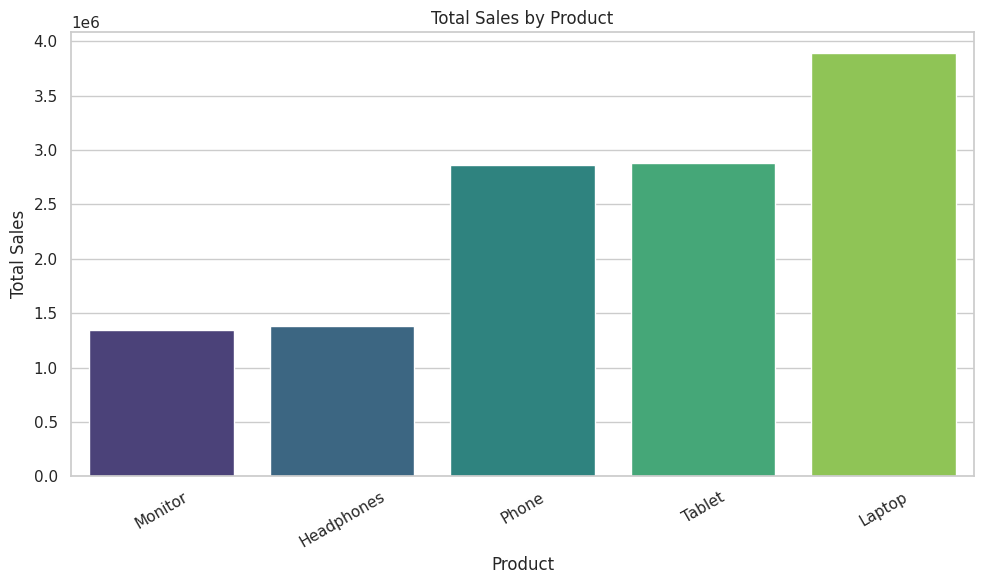

In [10]:
plt.figure(figsize=(10,6))

sales_product = df.groupby("Product")["Total_Sales"].sum().sort_values()

sns.barplot(
    x=sales_product.index,
    y=sales_product.values,
    palette="viridis"
)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("visualizations/sales_by_product.png")

plt.show()

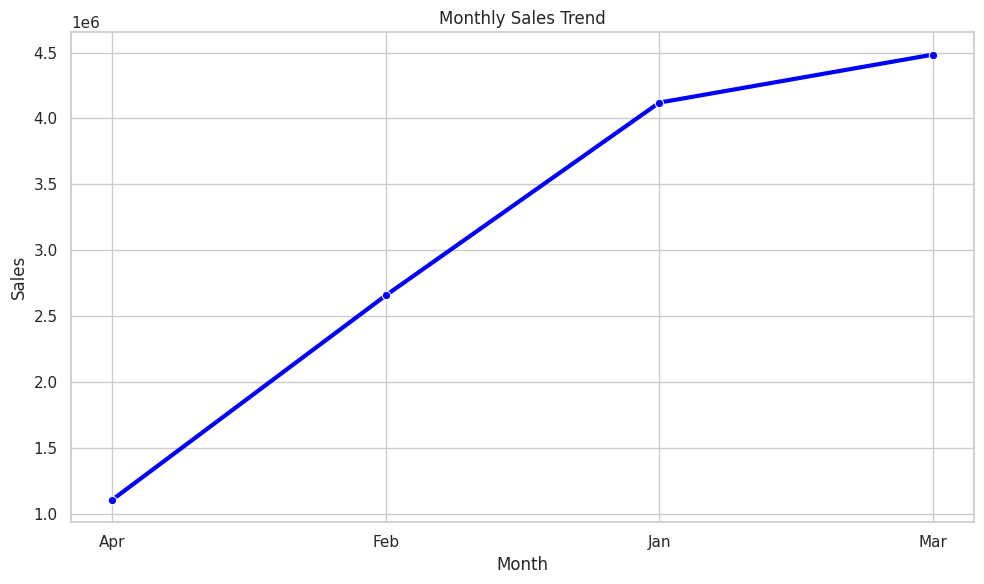

In [11]:
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=3,
    color="blue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("visualizations/monthly_sales.png")

plt.show()

/tmp/ipykernel_16374/3133361702.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




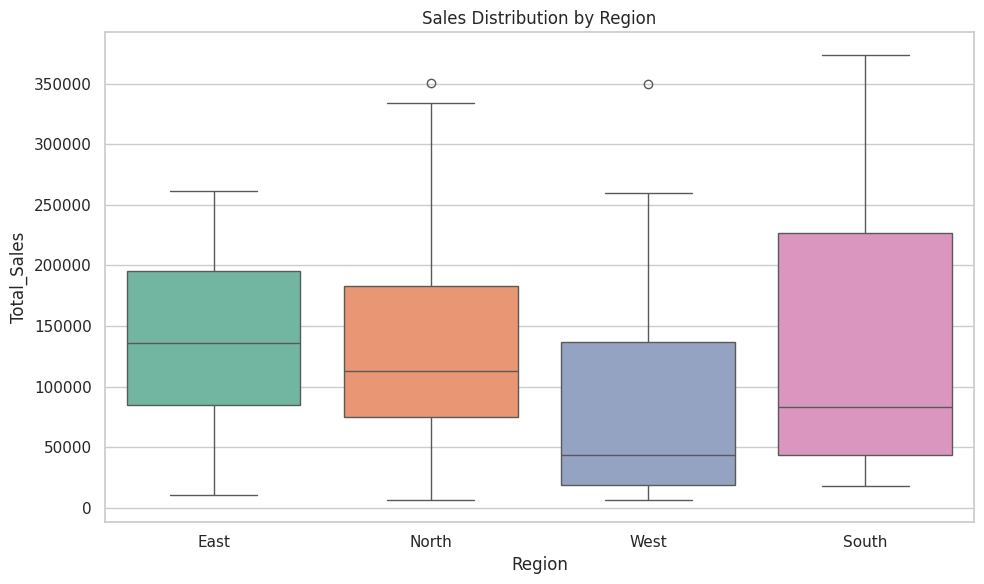

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Region",
    y="Total_Sales",
    data=df,
    palette="Set2"
)

plt.title("Sales Distribution by Region")

plt.tight_layout()

plt.savefig("visualizations/boxplot.png")

plt.show()

/tmp/ipykernel_16374/1494879373.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




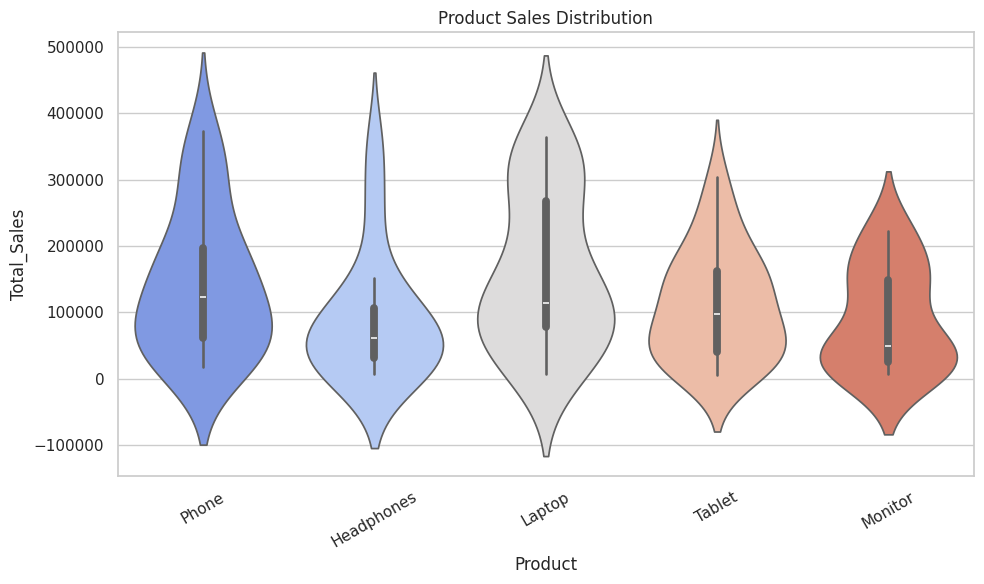

In [13]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x="Product",
    y="Total_Sales",
    data=df,
    palette="coolwarm"
)

plt.title("Product Sales Distribution")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("visualizations/violinplot.png")

plt.show()

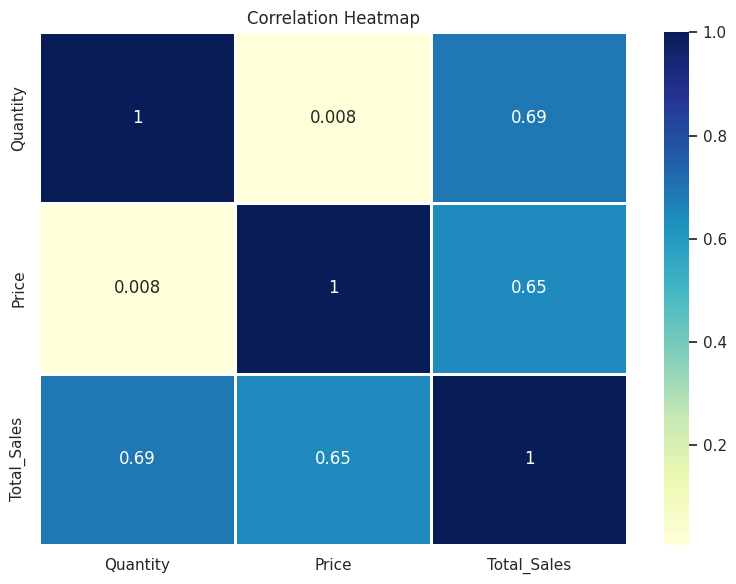

In [14]:
plt.figure(figsize=(8,6))

corr = df[["Quantity","Price","Total_Sales"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("visualizations/heatmap.png")

plt.show()

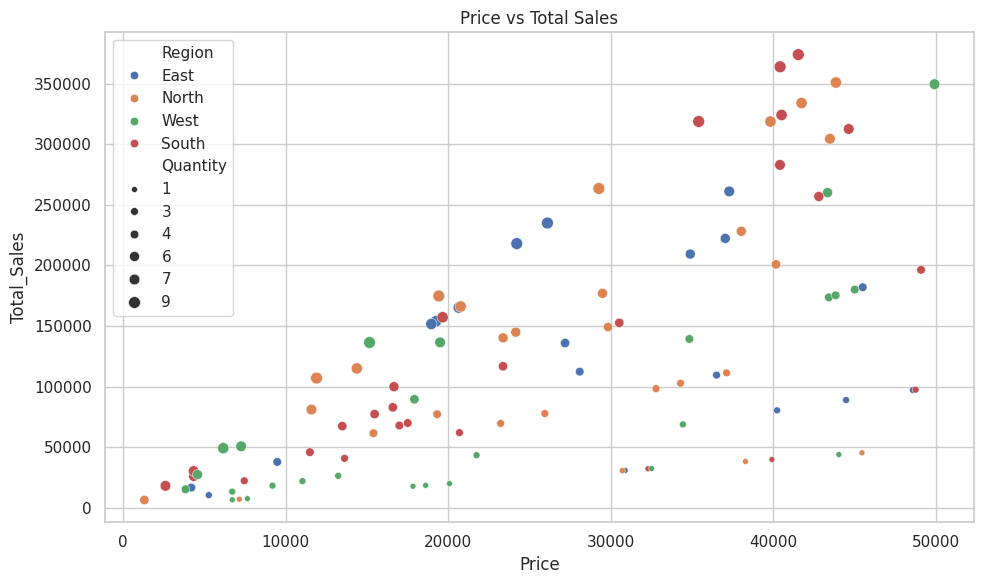

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Total_Sales",
    hue="Region",
    size="Quantity"
)

plt.title("Price vs Total Sales")

plt.tight_layout()

plt.savefig("visualizations/scatter_plot.png")

plt.show()

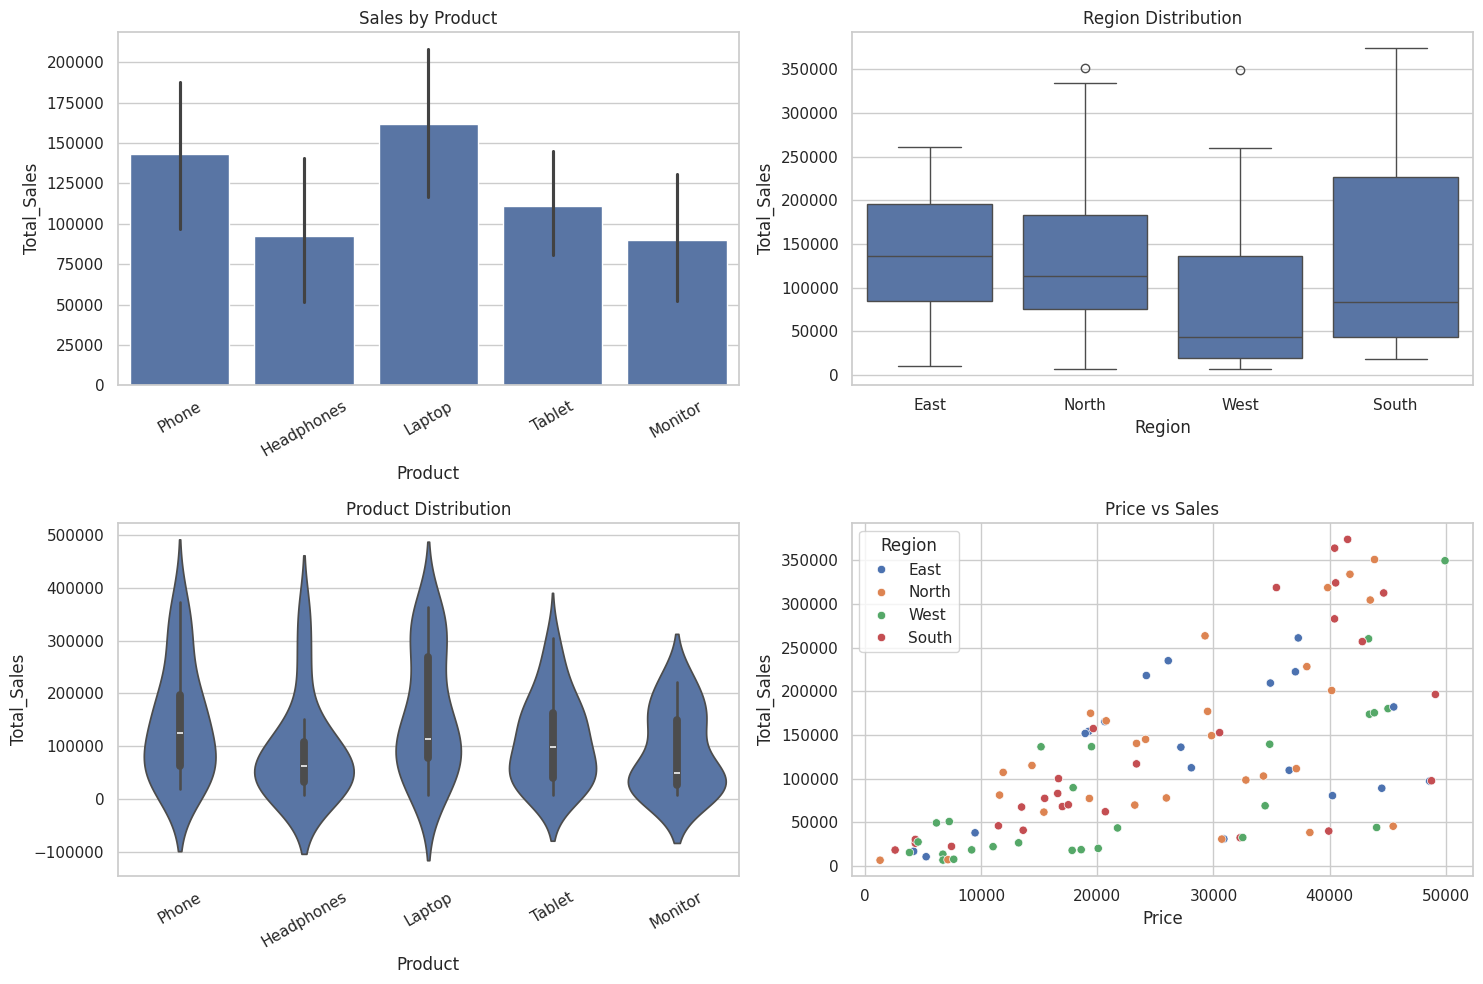

In [16]:


fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.barplot(
    data=df,
    x="Product",
    y="Total_Sales",
    ax=axes[0,0]
)
axes[0,0].set_title("Sales by Product")
axes[0,0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=df,
    x="Region",
    y="Total_Sales",
    ax=axes[0,1]
)
axes[0,1].set_title("Region Distribution")

sns.violinplot(
    data=df,
    x="Product",
    y="Total_Sales",
    ax=axes[1,0]
)
axes[1,0].set_title("Product Distribution")
axes[1,0].tick_params(axis='x', rotation=30)

sns.scatterplot(
    data=df,
    x="Price",
    y="Total_Sales",
    hue="Region",
    ax=axes[1,1]
)
axes[1,1].set_title("Price vs Sales")

plt.tight_layout()

plt.savefig("visualizations/dashboard.png")

plt.show()

In [17]:


fig = px.scatter(
    df,
    x="Price",
    y="Total_Sales",
    color="Region",
    size="Quantity",
    hover_name="Product",
    hover_data=["Customer_ID"],
    title="Interactive Sales Dashboard"
)

fig.show()


fig = px.bar(
    df,
    x="Product",
    y="Total_Sales",
    color="Region",
    title="Interactive Product Sales"
)

fig.show()



fig = px.pie(
    df,
    names="Product",
    values="Total_Sales",
    title="Sales Contribution by Product"
)

fig.show()

In [18]:
print("\n" + "=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print("\nHighest Selling Product:")
print(df.groupby("Product")["Total_Sales"].sum().idxmax())

print("\nHighest Sales Region:")
print(df.groupby("Region")["Total_Sales"].sum().idxmax())

print("\nTotal Revenue:")
print(df["Total_Sales"].sum())

print("\nAverage Sale:")
print(round(df["Total_Sales"].mean(),2))

print("\nHighest Sale:")
print(df["Total_Sales"].max())

print("\nLowest Sale:")
print(df["Total_Sales"].min())

print("\nTop 5 Customers:")
print(df.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False).head())

print("\nDashboard Completed Successfully!")


BUSINESS INSIGHTS

Highest Selling Product:
Laptop

Highest Sales Region:
North

Total Revenue:
12365048

Average Sale:
123650.48

Highest Sale:
373932

Lowest Sale:
6540

Top 5 Customers:
Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
Name: Total_Sales, dtype: int64

Dashboard Completed Successfully!
